# Name - Aaroksh chauhan , Roll no. - 25CL05014
# Lab - 7

**OPENING THE FILE**

In [2]:
import xarray as xr

pt = "C:/Users/user/Desktop/Aaroksh/HadlSST/HadISST_sst.nc"
ds = xr.open_dataset(pt)
ds

<xarray.Dataset>
Dimensions:    (time: 1868, nv: 2, latitude: 180, longitude: 360)
Coordinates:
  * time       (time) datetime64[ns] 1870-01-16T11:59:59.505615234 ... 2025-0...
  * latitude   (latitude) float32 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float32 -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) float32 ...
    sst        (time, latitude, longitude) float32 ...
Attributes:
    Title:                      Monthly version of HadISST sea surface temper...
    description:                HadISST 1.1 monthly average sea surface tempe...
    institution:                Met Office Hadley Centre
    source:                     HadISST
    reference:                  Rayner, N. A., Parker, D. E., Horton, E. B., ...
    Conventions:                CF-1.0
    history:                    6/10/2025 converted to netcdf from pp format
    supplementary_information:  Updates and supplementary information will be...
    comment:                    Data restrictions: for academic research use ...

***PICKING UP RANDOM 360 VALUES FROM A TOTAL OF 1868 STEPS , CACULATING THEIR MEAN AND ITERATING IT FOR 10000 TIMES***

In [50]:
import numpy as np
import random
SST = ds["sst"]
np.random.seed(42)                                                          # DOING THIS WILL NOT CHANGE THE OUTCOMES GENERATED
regional_sst = SST.sel(latitude=slice(5,-5), longitude=slice(-170,-120))    # SELECTING THE LAT , LONG OF NINO 3.4 AREA 
areal_mean = regional_sst.mean(dim = ['latitude','longitude'])              # CALCULATING THE AREAL MEAN   

times = areal_mean.sizes['time']                                            # CALCULATING THE SIZE OF TIME STEPS
print('The total no of time steps is',times)
a =10000
num_data = np.zeros([a,1])         #Creating an array using np.zeros 
for i in range(a):
    rand_steps = np.random.choice(areal_mean,360,replace=False)             # PICKING UP RANDOM 360 NON REPEATING STEPS OUT OF TOTAL 1868 STEPS
    num_data[i] = np.mean(rand_steps)                                       # STORING THESE VALUES INTO THE ALREADY CREATED EMPTY ARRAY
   
print(num_data)                           
    
    


The total no of time steps 1868
[[26.92771339]
 [27.01779175]
 [26.89641571]
 ...
 [26.87082863]
 [26.98929024]
 [26.89883041]]


***PLOTTING THE HISTOGRAM OF THE ABOVE MEAN VALUES OBTAINED***

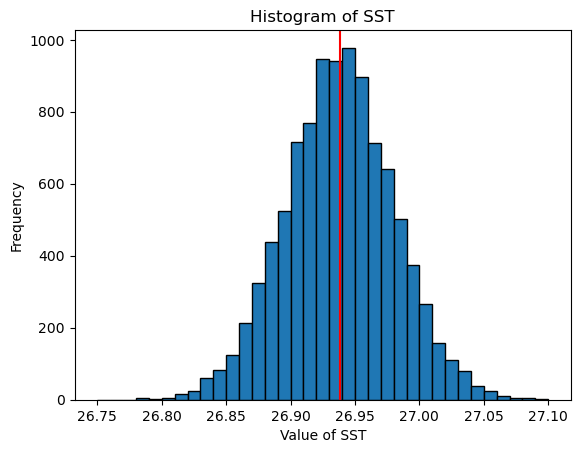

In [49]:
import matplotlib.pyplot as plt
mean_total = np.mean(areal_mean)
max = np.nanmax(num_data)                              # FINDING THE MAXIMUM VALUE OF MEAN VALUE
bin_edges = np.arange(26.75,max,0.01)                  # DEFINING THE BIN EDGES 
plt.hist(num_data,bins = bin_edges,edgecolor='Black')
plt.axvline(mean_total,color='red')
plt.title('Histogram of SST')
plt.xlabel('Value of SST')
plt.ylabel('Frequency')
plt.show()